In [1]:
import pandas as pd
import numpy as np
import sqlite3
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Загружаем данные
conn = sqlite3.connect('books_database.db')
df = pd.read_sql_query('SELECT * FROM books', conn)
conn.close()

print(f"✅ Загружено: {len(df)} книг")

✅ Загружено: 100 книг


In [2]:
# Подготовка данных
df['price_clean'] = df['price'].str.replace('Â£', '').astype(float)
rating_map = {'Five': 5, 'Four': 4, 'Three': 3, 'Two': 2, 'One': 1}
df['rating_num'] = df['rating'].map(rating_map)
df['page_num'] = df['page']

# Признаки и целевая
X = df[['rating_num', 'page_num']].values
y = df['price_clean'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📚 Train: {len(X_train)} | 🧪 Test: {len(X_test)}")

📚 Train: 80 | 🧪 Test: 20


In [3]:
# === СРАВНЕНИЕ 3 МОДЕЛЕЙ ===

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    results.append({
        'model': name,
        'R²': r2,
        'MSE': mse
    })
    
    print(f"📊 {name}:")
    print(f"   R²: {r2:.4f}")
    print(f"   MSE: {mse:.4f}")
    print()

# Таблица результатов
results_df = pd.DataFrame(results)
print("🏆 СРАВНЕНИЕ МОДЕЛЕЙ:")
print(results_df.sort_values('R²', ascending=False))

📊 Linear Regression:
   R²: 0.0501
   MSE: 153.5288

📊 Decision Tree:
   R²: -0.2356
   MSE: 199.7128

📊 Random Forest:
   R²: -0.2148
   MSE: 196.3431

🏆 СРАВНЕНИЕ МОДЕЛЕЙ:
               model        R²         MSE
0  Linear Regression  0.050097  153.528766
2      Random Forest -0.214800  196.343087
1      Decision Tree -0.235649  199.712798


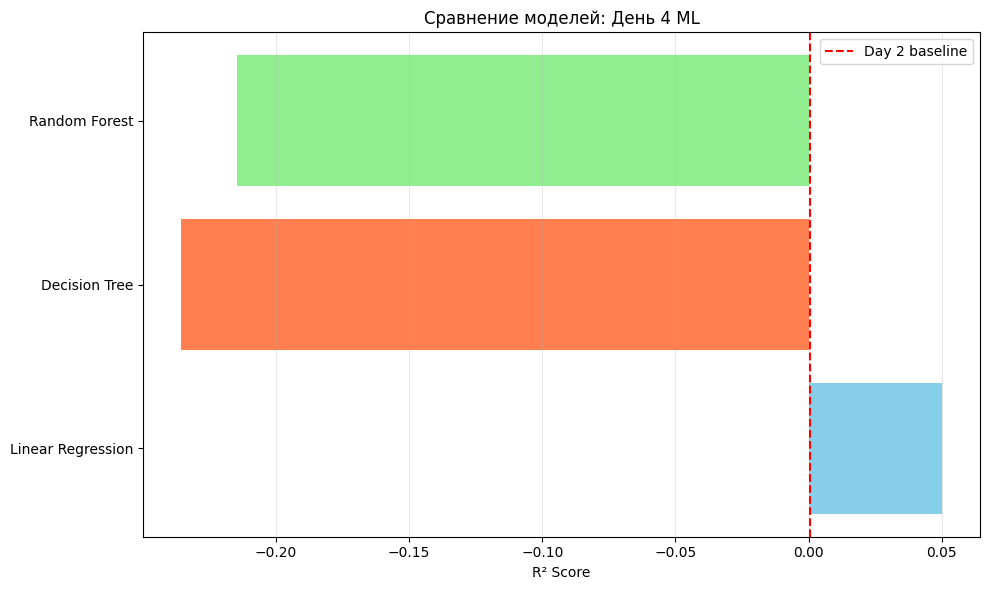

In [4]:
# Визуализация сравнения
plt.figure(figsize=(10, 6))

# Барчарт R²
plt.barh([r['model'] for r in results], [r['R²'] for r in results], 
         color=['skyblue', 'coral', 'lightgreen'])
plt.xlabel('R² Score')
plt.title('Сравнение моделей: День 4 ML')
plt.grid(axis='x', alpha=0.3)

# Линия "базовый уровень" (Day 2)
plt.axvline(x=0.0007, color='red', linestyle='--', label='Day 2 baseline')
plt.legend()

plt.tight_layout()
plt.show()


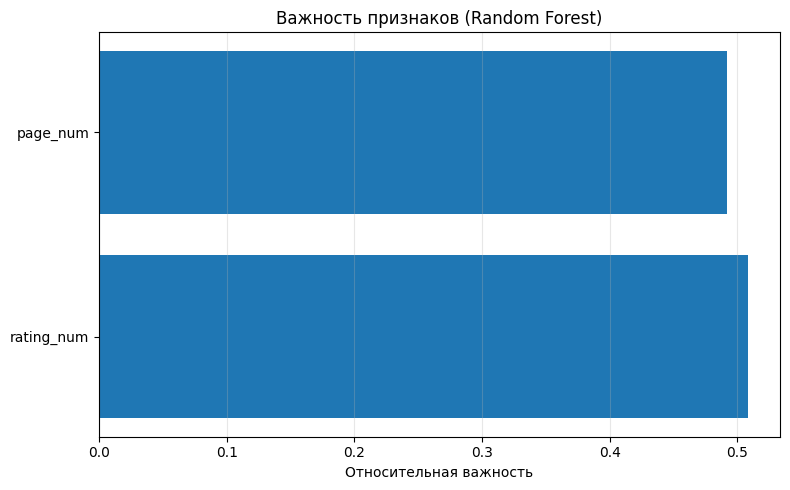

📊 Важность признаков:
   rating_num: 0.5080
   page_num: 0.4920


In [5]:
# Важность признаков (только для Random Forest)
rf_model = models['Random Forest']
feature_names = ['rating_num', 'page_num']

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title('Важность признаков (Random Forest)')
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Относительная важность')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 Важность признаков:")
for i in indices:
    print(f"   {feature_names[i]}: {importances[i]:.4f}")